In [1]:
import meep as mp
import meep.adjoint as mpa
from meep.materials import Au, Ag 
import numpy as np
from autograd import numpy as npa
from autograd import tensor_jacobian_product, grad
import nlopt
from matplotlib import pyplot as plt
from matplotlib.patches import Circle
import time
import os
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1 import make_axes_locatable
import pandas as pd

In [2]:
dir_path = 'post-harm'
os.makedirs(dir_path, exist_ok=True)

In [3]:
mp.verbosity(1)
Air = mp.Medium(index=1)
Si = mp.Medium(index = 3.48)
resolution = 250 
dx = 0.9  #design_region_x_width = 1    
dy = 0.9  #design_region_y_width = 1   
pml_size = 0.8
air_size = 0.3
Sx = dx
Sy = dy + 2*pml_size + 2*air_size
cell_size = mp.Vector3(Sx, Sy)

# Mapping parameters
minimum_length = 0.01
eta_i = 0.5
eta_e = 0.55
eta_d = 1 - eta_e
filter_radius = mpa.get_conic_radius_from_eta_e(minimum_length, eta_e)
design_region_resolution = int(resolution)
pml_layers = [mp.PML(thickness=pml_size, direction=mp.Y)]

monitor_position = mp.Vector3(Sx/2 - pml_size - 0.1, 0, 0)
monitor_size1 = mp.Vector3(0, dy, 0)

# Design frequency
wavelengths = np.array([1.55])
frequencies = np.array([1 / 1.55])
fcen = 1. / 1.55
width = 0.2
fwidth = width * fcen
source_center = mp.Vector3(-Sx/2,0) 
src_size = dy + 2* air_size
source_size = mp.Vector3(0,src_size) 
src = mp.GaussianSource(frequency=fcen, fwidth=fwidth)
source = [mp.Source(src, component=mp.Ey, size=source_size, center=source_center)]
# Design weight

Nx = int(design_region_resolution * dx) + 1
Ny = int(design_region_resolution * dy) + 1
design = np.load("data/final_design.npy")
design = design.reshape(Nx,Ny)
design_variables = mp.MaterialGrid(mp.Vector3(Nx, Ny), Air, Si,weights=design, grid_type="U_MEAN")
design_region = mpa.DesignRegion(
    design_variables,
    volume=mp.Volume(
        center=mp.Vector3(0, 0, 0),
        size=mp.Vector3(dx, dy, 0),
    ),
)



# Setting geometry
geometry = [   
    mp.Block(center=design_region.center, size=design_region.size, material=design_variables),
]



# Main simulation
sim = mp.Simulation(
    cell_size=cell_size,
    boundary_layers=pml_layers,
    geometry=geometry,
    sources=source,
    default_material=Air,
    resolution=resolution,
    k_point=mp.Vector3(),
    extra_materials=[Si],
) 

     block, center = (0,0,0)
          size (0.9,0.9,0)


          axes (1,0,0), (0,1,0), (0,0,1)


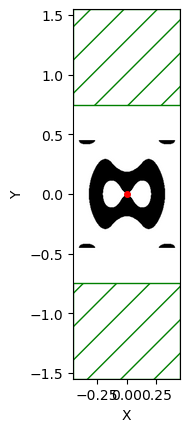

In [4]:
src = mp.GaussianSource(frequency=fcen, fwidth=1)
source = [mp.Source(src, component=mp.Ey, size=mp.Vector3(0,0), center=mp.Vector3(0,0))]
sim.change_sources(source)
sim.plot2D()
plt.show()
plt.close()


In [5]:
harminv_pt = mp.Vector3(0, 0)
h = mp.Harminv(mp.Ey, pt=harminv_pt, fcen=fcen, df=1)

# 執行模擬直到模態衰減
sim.run(mp.after_sources(h), until=2000)

# 擷取結果


-----------
Initializing structure...
time for choose_chunkdivision = 0.000162125 s
Working in 2D dimensions.
Computational cell is 0.9 x 3.1 x 0 with resolution 250
     block, center = (0,0,0)
          size (0.9,0.9,0)
          axes (1,0,0), (0,1,0), (0,0,1)
time for set_epsilon = 0.332576 s
-----------


FloatProgress(value=0.0, description='0% done ', max=2000.0)

Meep progress: 7.212/2000.0 = 0.4% done in 4.0s, 1105.5s to go
on time step 3608 (time=7.216), 0.00110886 s/step
Meep progress: 14.714/2000.0 = 0.7% done in 8.0s, 1079.6s to go
on time step 7360 (time=14.72), 0.00106634 s/step
Meep progress: 21.89/2000.0 = 1.1% done in 12.0s, 1084.6s to go
on time step 10948 (time=21.896), 0.00111489 s/step
Meep progress: 32.294000000000004/2000.0 = 1.6% done in 16.0s, 975.1s to go
on time step 16155 (time=32.31), 0.000768286 s/step
Meep progress: 45.534/2000.0 = 2.3% done in 20.0s, 858.6s to go
on time step 22775 (time=45.55), 0.000604242 s/step
Meep progress: 58.844/2000.0 = 2.9% done in 24.0s, 791.8s to go
on time step 29431 (time=58.862), 0.000601002 s/step
Meep progress: 72.33/2000.0 = 3.6% done in 28.0s, 746.3s to go
on time step 36175 (time=72.35), 0.000593136 s/step
Meep progress: 85.928/2000.0 = 4.3% done in 32.0s, 712.9s to go
on time step 42975 (time=85.95), 0.000588275 s/step
Meep progress: 99.47/2000.0 = 5.0% done in 36.0s, 687.9s to go
on

In [6]:
data = [
    {
        "frequency": mode.freq,
        "decay": mode.decay,
        "Q": mode.Q,
        "abs_amplitude": abs(mode.amp),
        "amplitude": mode.amp,
        "error": mode.err,
    }
    for mode in h.modes  # 過濾低 Q 或雜訊模態
]

df = pd.DataFrame(data)
df.to_csv(f"{dir_path}/harminv_qfactor.csv", index=False)
print(df)

   frequency         decay             Q  abs_amplitude  \
0   0.653277 -6.567448e-09  4.973602e+07     225.414737   
1   1.045418 -8.897172e-06  5.875001e+04       2.907524   

               amplitude                                           error  
0  24.087813-224.124030j  3.570462e-12+0.000000e+                    00j  
1  -0.377417+  2.882924j  5.362040e-10+0.000000e+                    00j  
